In [1]:
                                                      #TITLE AND OBJECTIVE OF THE PROJECT
                                                                #CLUSTERING
#The purpose of this project is to analyze customer personalities and behaviors to segment customers into meaningful groups, so that the business can:
#Understand who their customers really are
#Identify which types of customers behave similarly
#Target marketing campaigns more effectively
#Optimize product offerings for different segments
#Instead of treating all customers the same, the company wants to market smarter, not louder.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [4]:
df = pd.read_csv('CustomerMarketing.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
#The income feature has around 24 null values.

In [8]:
df['Income'].isna().sum()
median_income = df['Income'].median()
df['Income'] = df['Income'].fillna(median_income)
df['Income'].isna().sum()

np.int64(0)

In [9]:
                                                            #EXPLORATORY DATA ANALYSIS


In [10]:
#CALCULATING AGE BASED ON BIRTH YEAR
from datetime import datetime
current_year = datetime.now().year
df['Age'] = current_year - df['Year_Birth']

In [11]:
df[['Year_Birth','Age']].head(5)

,Year_Birth,Age
0,1957,69
1,1954,72
2,1965,61
3,1984,42
4,1981,45


In [12]:
df.drop(columns=['Year_Birth'],inplace=True)

In [13]:
summary = df.describe().T
summary['mode'] = df.mode().iloc[0]
summary

,count,mean,std,min,25%,50%,75%,max,mode
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0,0
Income,2240.0,52237.975446,25037.955891,1730.0,35538.75,51381.5,68289.75,666666.0,51381.5
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0,0.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0,0.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0,56.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0,2.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0,0.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0,7.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0,0.0
MntSweetProducts,2240.0,27.062946,41.280498,0.0,1.00,8.0,33.00,263.0,0.0


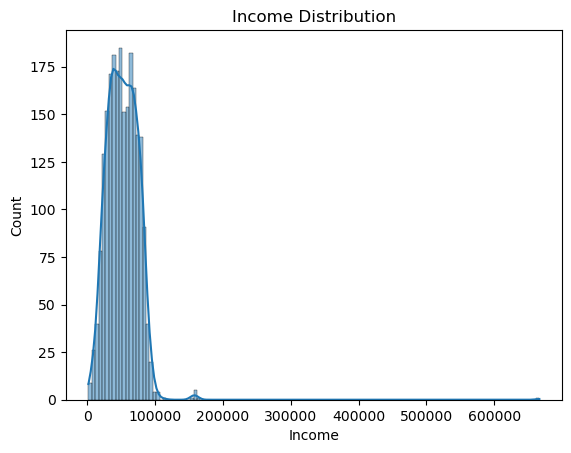

In [14]:
sns.histplot(df['Income'],kde=True)
plt.title('Income Distribution')
plt.show()

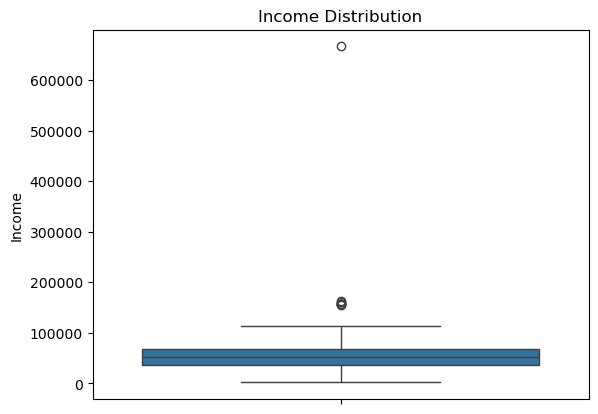

In [15]:
sns.boxplot(y=df['Income'])
plt.title('Income Distribution')
plt.show()

In [16]:
#The box and hist plots show that the customers income is highly distributed between 0 to 100000 with few extreme high income customers indicating right skewness. 
#Keeping the outliers as is for better clustering since the high income customers could be premium or most valuable customers.

In [17]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'],format='%d-%m-%Y')
today = datetime.now()
df['Customer_Tenure_Years'] = (today - df['Dt_Customer']).dt.days/365
df['Customer_Tenure_Years'] = df['Customer_Tenure_Years'].round(1)
df['Customer_Tenure_Years'].head()

0    13.4
1    11.9
2    12.5
3    12.0
4    12.1
Name: Customer_Tenure_Years, dtype: float64

In [18]:
df.drop(columns=['Dt_Customer'],inplace=True)

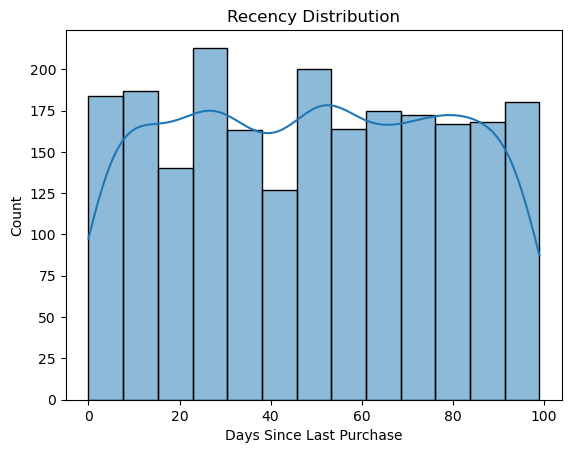

In [19]:
sns.histplot(df['Recency'], kde=True)
plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Count")
plt.show()

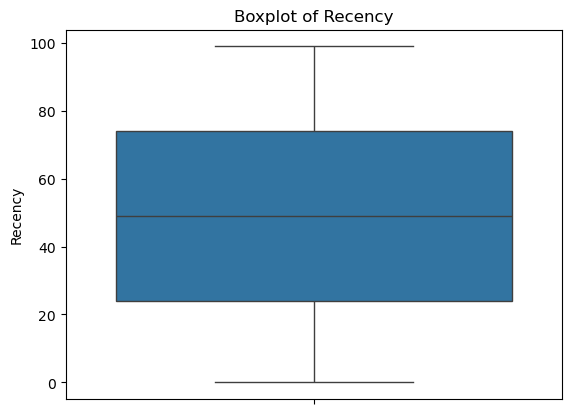

In [20]:
sns.boxplot(y=df['Recency'])
plt.title("Boxplot of Recency")
plt.show()

In [21]:
#Recency analysis shows varying levels of customer engagement, with lower values indicating highly active customers and higher values 
#representing inactive or dormant customers.

In [22]:
#Merging Spending features into one 
spending_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]
df['Total_Spending'] = df[spending_cols].sum(axis=1)

In [23]:
df['Total_Spending'].head(5)
df['Total_Spending'].describe()

count    2240.000000
mean      605.798214
std       602.249288
min         5.000000
25%        68.750000
50%       396.000000
75%      1045.500000
max      2525.000000
Name: Total_Spending, dtype: float64

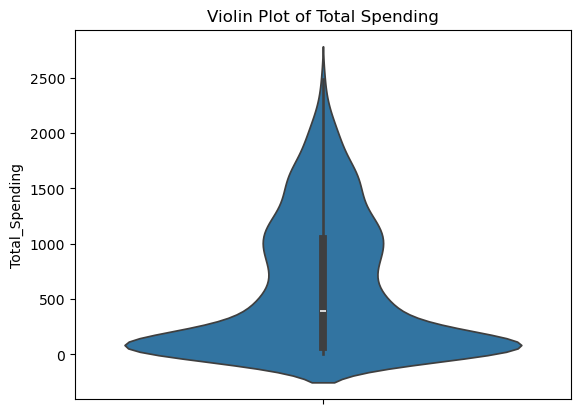

In [24]:
sns.violinplot(y=df['Total_Spending'])
plt.title("Violin Plot of Total Spending")
plt.show()

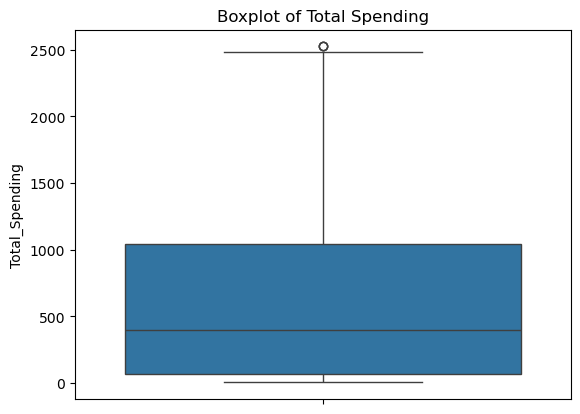

In [25]:
sns.boxplot(y=df['Total_Spending'])
plt.title("Boxplot of Total Spending")
plt.show()

In [26]:
#We have merged amount spent for different products into one single feature called Total Spending. Total spending highly right skewed with few customers
#spending higher than the average customers. Keeping the outliers as is since the high spending customers could be priviliged customers.

In [27]:
df.drop(columns=spending_cols, inplace=True)

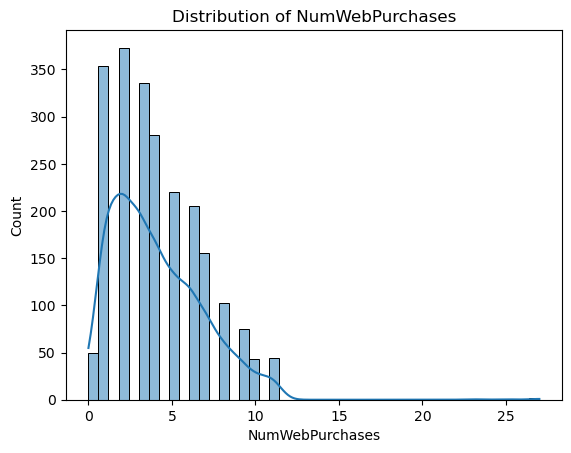

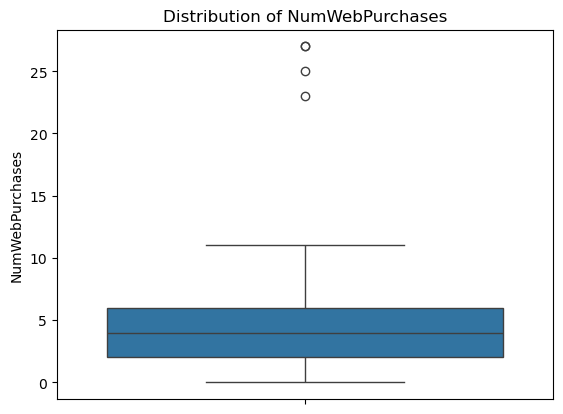

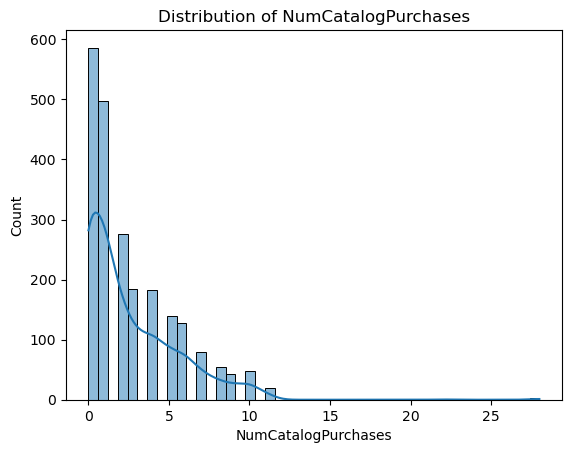

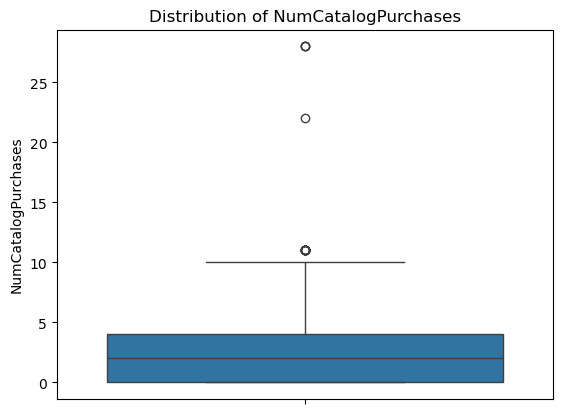

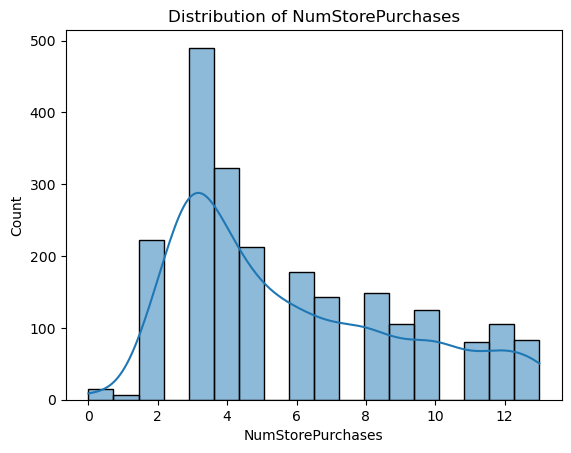

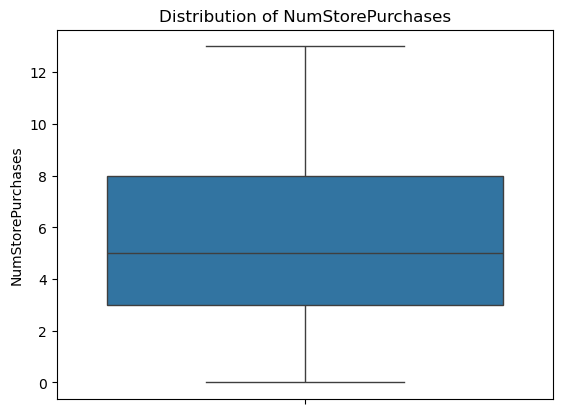

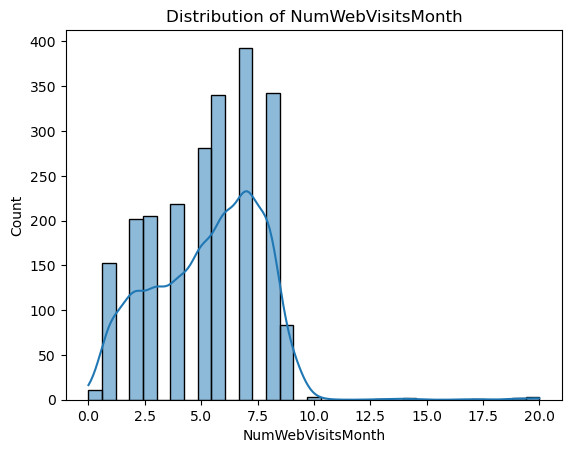

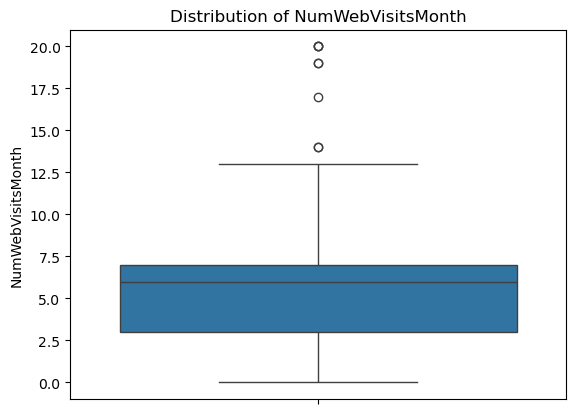

In [28]:
#DEALS FEATURE
channel_cols = ['NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth']

for col in channel_cols:
    sns.histplot(df[col],kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

    sns.boxplot(y=df[col])
    plt.title(f"Distribution of {col}")
    plt.show()

In [29]:
#Web purchases show a right-skewed distribution with most customers making between 2–6 purchases, while a small number of customers exhibit 
#very high online purchasing activity.
#Catalog purchases are relatively low for most customers, indicating that catalog-based shopping is used by a limited subset of customers.
#Store purchases exhibit a wider and more balanced distribution, suggesting that in-store shopping remains a dominant purchasing channel.
#Website visit frequency is higher than web purchase frequency, indicating the presence of browsing behavior without immediate purchase for several 
#customers.

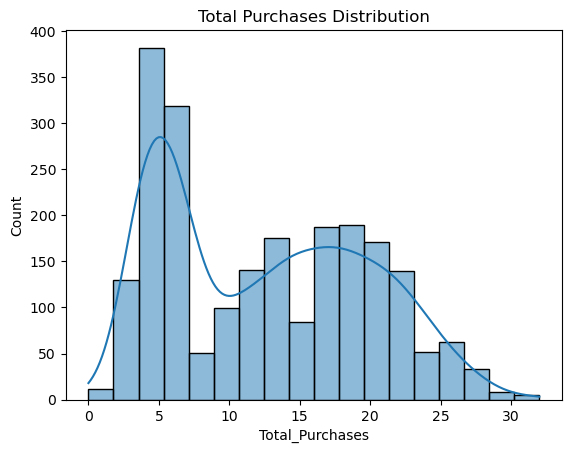

In [30]:
df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

sns.histplot(df['Total_Purchases'], kde=True)
plt.title("Total Purchases Distribution")
plt.show()


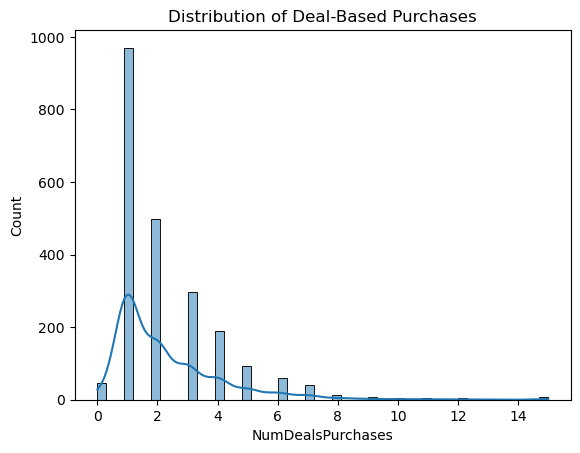

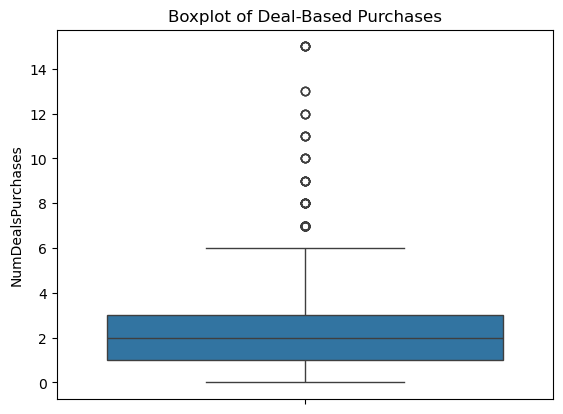

In [31]:
sns.histplot(df['NumDealsPurchases'], kde=True)
plt.title("Distribution of Deal-Based Purchases")
plt.show()

sns.boxplot(y=df['NumDealsPurchases'])
plt.title("Boxplot of Deal-Based Purchases")
plt.show()

In [32]:
#NumDealsPurchases was analyzed to assess customer price sensitivity. Higher values indicate customers who predominantly purchase 
#during promotional offers.Outliers were not removed since high-value customers are important for segmentation and represent meaningful business behavior.

In [33]:
df['Deal_purchase_ratio'] = df['NumDealsPurchases'] / (df['Total_Purchases'] + 1)
df['Deal_purchase_ratio'].head()

0    0.130435
1    0.400000
2    0.047619
3    0.285714
4    0.333333
Name: Deal_purchase_ratio, dtype: float64

In [34]:
#The Deal Purchase Ratio tells us what percentage of purchases depend on deals.

In [35]:
df.drop(columns=[
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
], inplace=True)

In [36]:
#CAMPAIGN FEATURES
campaign_cols = ['AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5',
    'Response']
df['Campaign_Response_Count'] = df[campaign_cols].sum(axis=1)

In [37]:
df[['Campaign_Response_Count']].head()
df['Campaign_Response_Count'].value_counts()

Campaign_Response_Count
0    1631
1     370
2     142
3      51
4      36
5      10
Name: count, dtype: int64

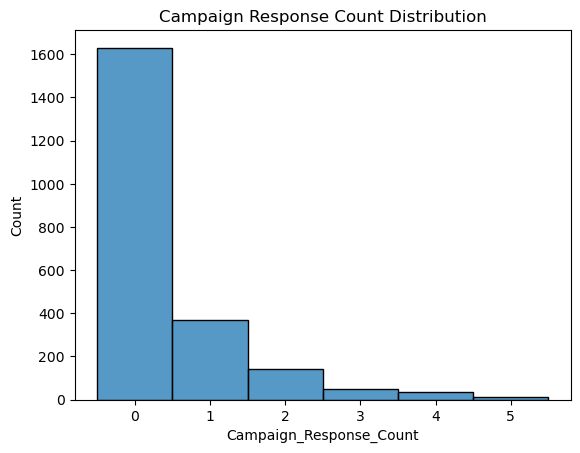

In [38]:
sns.histplot(df['Campaign_Response_Count'], discrete=True)
plt.title("Campaign Response Count Distribution")
plt.show()

In [39]:
#The Campaign_Response_Count feature ranges from 0 to 5, indicating varying levels of customer responsiveness to marketing campaigns, 
#with the majority of customers showing low to moderate engagement.

In [40]:
df.drop(columns=campaign_cols, inplace=True)

In [41]:
df['Complain'].value_counts()

Complain
0    2219
1      21
Name: count, dtype: int64

In [42]:
#The complain feature indicates a few people shows dissatisfaction. Hence keeping the feature as is.

In [43]:
df['Z_CostContact'].value_counts()

Z_CostContact
3    2240
Name: count, dtype: int64

In [44]:
df['Z_Revenue'].value_counts()

Z_Revenue
11    2240
Name: count, dtype: int64

In [45]:
df.drop(columns=['Z_CostContact','Z_Revenue'], inplace=True)

In [46]:
#Z_CostContact and Z_Revenue were removed since they contained constant values across all observations and provided no discriminatory power for clustering.

In [47]:
#CATEGORICAL FEATURES
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [48]:
#Ordinal Encoding because education follows a natural progression
edu_map = {
    'Basic': 1,
    '2n Cycle': 2,
    'Graduation': 3,
    'Master': 4,
    'PhD': 5
}
df['Education_Level'] = df['Education'].map(edu_map)

In [49]:
df[['Education', 'Education_Level']].head()
df['Education_Level'].value_counts()

Education_Level
3    1127
5     486
4     370
2     203
1      54
Name: count, dtype: int64

In [50]:
df.drop(columns=['Education'], inplace=True)

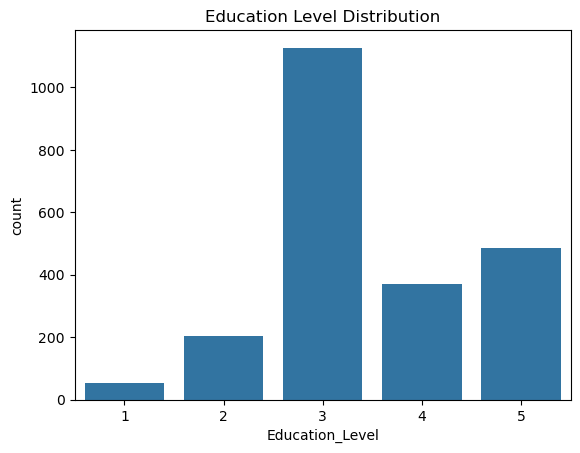

In [51]:
sns.countplot(x='Education_Level', data=df)
plt.title("Education Level Distribution")
plt.show()

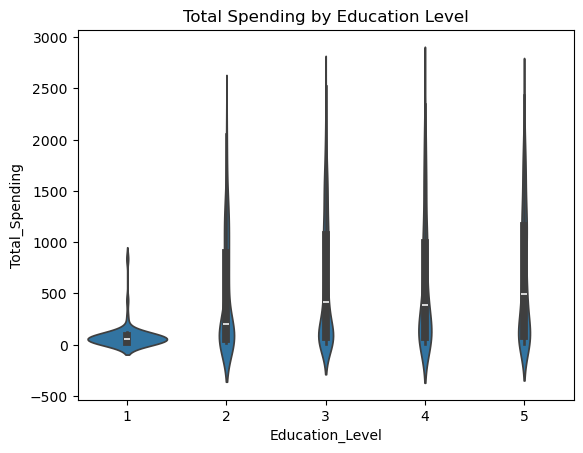

In [52]:
sns.violinplot(x='Education_Level', y='Total_Spending', data=df)
plt.title("Total Spending by Education Level")
plt.show()

In [53]:
#Customers with higher education levels tend to exhibit higher median total spending. In particular, customers with a Master’s degree show 
#the highest spending tendency among all education groups.

In [54]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [55]:
#Merging odd lables into sensible groups to reduce the noise
df['Marital_Status'] = df['Marital_Status'].replace({
    'Alone': 'Single',
    'YOLO': 'Single',
    'Absurd': 'Single'
})

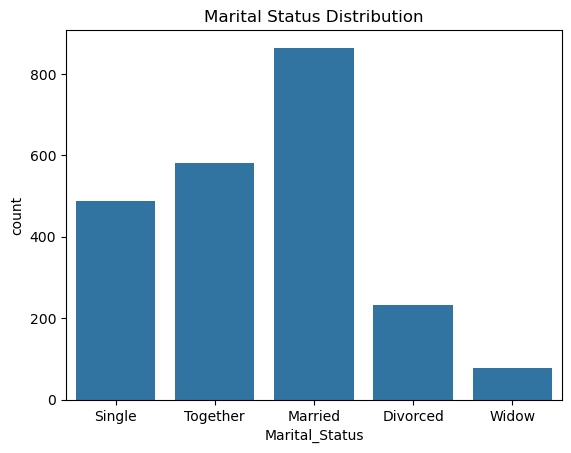

In [56]:
sns.countplot(x='Marital_Status', data=df)
plt.title("Marital Status Distribution")
plt.show()

In [57]:
df = pd.get_dummies(df, columns=['Marital_Status'], drop_first=True)

In [58]:
df['Children_Count'] = df['Kidhome'] + df['Teenhome']

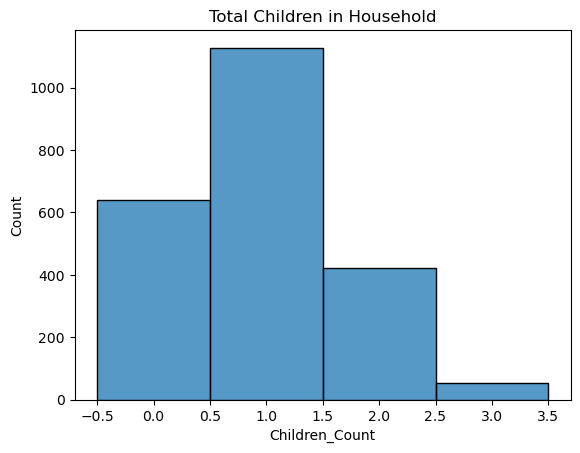

In [59]:
sns.histplot(df['Children_Count'], discrete=True)
plt.title("Total Children in Household")
plt.show()

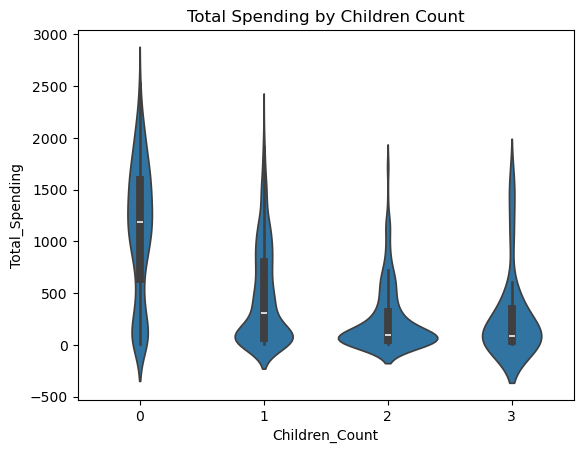

In [60]:
sns.violinplot(x='Children_Count', y='Total_Spending', data=df)
plt.title("Total Spending by Children Count")
plt.show()

In [61]:
df.drop(columns=['Kidhome','Teenhome'], inplace=True)

In [62]:
#Violin plot analysis shows that customers without children exhibit the highest median total spending, while spending gradually decreases as 
#the number of children in the household increases, indicating greater discretionary purchasing power among child-free customers.

In [63]:
#APPLYING STANDARD SCALING TECHNIQUE 

In [64]:
X = df.drop(columns=['ID'])

In [65]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [66]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebVisitsMonth,Complain,Age,Customer_Tenure_Years,Total_Spending,Total_Purchases,Deal_purchase_ratio,Campaign_Response_Count,Education_Level,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Children_Count
0,58138.0,58,3,7,0,69,13.4,1617,22,0.130435,1,3,False,True,False,False,0
1,46344.0,38,2,5,0,72,11.9,27,4,0.400000,0,3,False,True,False,False,2
2,71613.0,26,1,4,0,61,12.5,776,20,0.047619,0,3,False,False,True,False,0
3,26646.0,26,2,6,0,42,12.0,53,6,0.285714,0,3,False,False,True,False,1
4,58293.0,94,5,5,0,45,12.1,422,14,0.333333,0,5,True,False,False,False,1


In [67]:
X_scaled[:5]

array([[ 0.23569584,  0.30703926,  0.34941394,  0.69390374, -0.09728167,
         0.98534473,  1.45326434,  1.67941681,  1.31354426, -0.19677571,
         0.62124825, -0.45838256, -0.79240582,  1.89725837, -0.59109863,
        -0.18867619, -1.2645053 ],
       [-0.23545419, -0.38366418, -0.16823634, -0.13046347, -0.09728167,
         1.23573295, -1.25108224, -0.96127545, -1.18502179,  0.35253135,
        -0.50191242, -0.45838256, -0.79240582,  1.89725837, -0.59109863,
        -0.18867619,  1.39636071],
       [ 0.77399892, -0.79808624, -0.68588662, -0.54264708, -0.09728167,
         0.3176428 , -0.16934361,  0.28267329,  1.03592581, -0.36553364,
        -0.50191242, -0.45838256, -0.79240582, -0.52707634,  1.69176504,
        -0.18867619, -1.2645053 ],
       [-1.02235542, -0.79808624, -0.16823634,  0.28172013, -0.09728167,
        -1.26814929, -1.07079247, -0.91809432, -0.90740334,  0.11964541,
        -0.50191242, -0.45838256, -0.79240582, -0.52707634,  1.69176504,
        -0.18867619

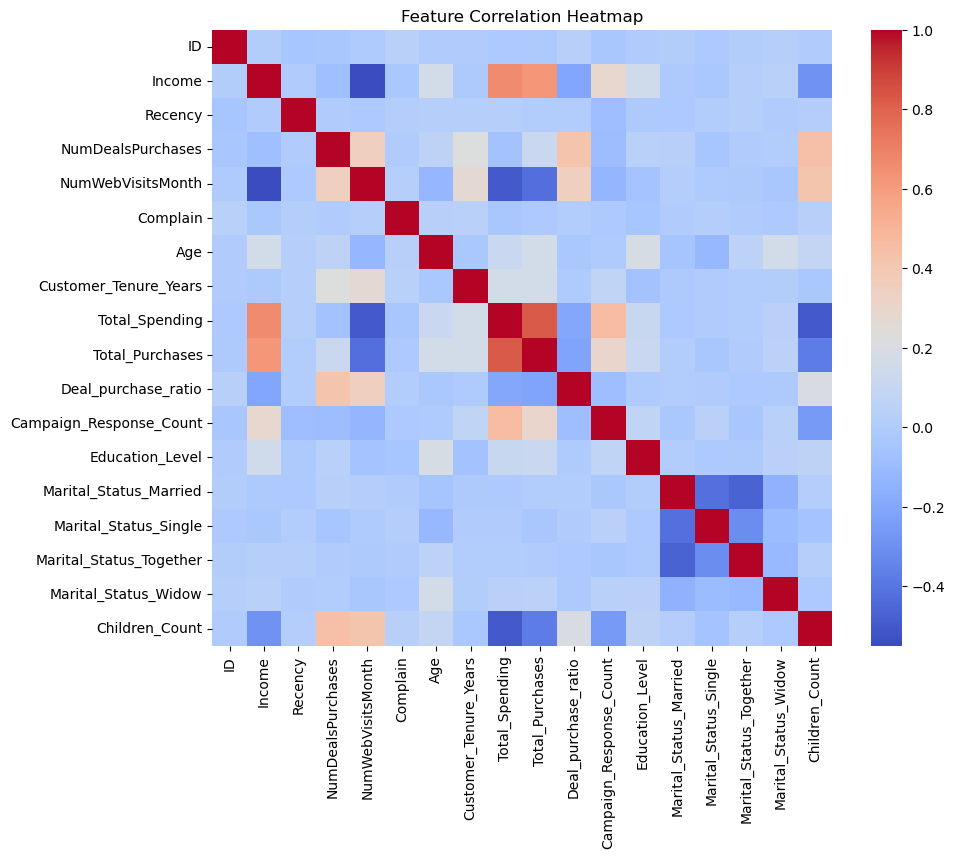

In [68]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [69]:
#The correlation heatmap indicates a strong positive relationship between Total_Purchases and Total_Spending, and a moderate positive relationship 
#between Income and Total_Spending. Children_Count shows a negative correlation with Total_Spending, indicating lower discretionary spending in larger 
#households. Overall, most features exhibit low inter-correlation, suggesting minimal redundancy and suitability for clustering.

In [70]:
pd.DataFrame(X_scaled).describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
count,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03
mean,-4.361590e-17,-3.172066e-18,-9.833404e-17,-6.344132e-17,-3.053113e-17,-1.681195e-16,-1.000787e-15,3.647876e-17,-1.118153e-16,-5.709718e-17,9.516197e-18,3.489272e-17,-6.344132e-17,6.344132e-17,7.137148e-17,-3.647876e-17,4.123686e-17
std,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00
min,-2.017707e+00,-1.696001e+00,-1.203537e+00,-2.191381e+00,-9.728167e-02,-2.269702e+00,-1.791952e+00,-9.978133e-01,-1.740259e+00,-4.625694e-01,-5.019124e-01,-2.450190e+00,-7.924058e-01,-5.270763e-01,-5.910986e-01,-1.886762e-01,-1.264505e+00
25%,-6.671053e-01,-8.671566e-01,-6.858866e-01,-9.548307e-01,-9.728167e-02,-6.839101e-01,-8.905027e-01,-8.919365e-01,-9.074033e-01,-3.058193e-01,-5.019124e-01,-4.583826e-01,-7.924058e-01,-5.270763e-01,-5.910986e-01,-1.886762e-01,-1.264505e+00
50%,-3.421472e-02,-3.777284e-03,-1.682363e-01,2.817201e-01,-9.728167e-02,-9.967091e-02,1.094616e-02,-3.484355e-01,-7.454799e-02,-8.628002e-02,-5.019124e-01,-4.583826e-01,-7.924058e-01,-5.270763e-01,-5.910986e-01,-1.886762e-01,6.592771e-02
75%,6.412408e-01,8.596020e-01,3.494139e-01,6.939037e-01,-9.728167e-02,8.184192e-01,9.123950e-01,7.302623e-01,7.583074e-01,1.668804e-01,6.212482e-01,5.375214e-01,1.261980e+00,-5.270763e-01,1.691765e+00,-1.886762e-01,6.592771e-02
max,2.454534e+01,1.722981e+00,6.561217e+00,6.052291e+00,1.027943e+01,6.326960e+00,1.633554e+00,3.187435e+00,2.701637e+00,3.010371e+01,5.113891e+00,1.533425e+00,1.261980e+00,1.897258e+00,1.691765e+00,5.300086e+00,2.726794e+00


In [71]:
from sklearn.cluster import KMeans

In [72]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

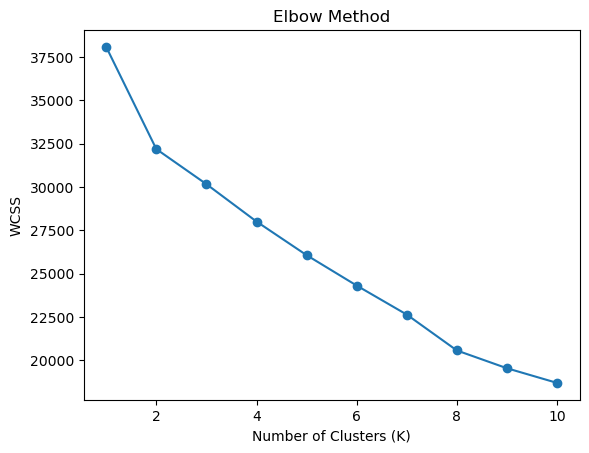

In [73]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [74]:
#The WCSS curve shows a sharp decrease up to K=4, after which the rate of decrease slows down, indicating diminishing returns. Hence, K=4 was selected as the optimal number of clusters.

In [75]:
n_clusters = 4

In [76]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

In [77]:
df['Cluster'].value_counts()

Cluster
3    778
2    593
1    536
0    333
Name: count, dtype: int64

In [78]:
cluster_profile = df.groupby('Cluster').mean()
cluster_profile

,ID,Income,Recency,NumDealsPurchases,NumWebVisitsMonth,Complain,Age,Customer_Tenure_Years,Total_Spending,Total_Purchases,Deal_purchase_ratio,Campaign_Response_Count,Education_Level,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Children_Count
Cluster,,,,,,,,,,,,,,,,,,
0,5392.384384,39566.591592,48.348348,2.453453,6.369369,0.012012,53.942943,12.583183,253.957958,8.792793,0.289741,0.276276,3.363363,0.000000,1.000000,0.000000,0.000000,1.168168
1,5492.751866,57307.113806,48.940299,4.264925,6.055970,0.009328,61.485075,12.850187,750.889925,17.089552,0.256014,0.345149,3.686567,0.449627,0.026119,0.309701,0.067164,1.276119
2,5653.397976,77349.147555,49.536256,1.101180,2.733558,0.005059,58.045531,12.534064,1337.062395,19.178752,0.057357,1.035413,3.526138,0.359191,0.236088,0.263069,0.042159,0.193929
3,5699.478149,35029.219152,49.226221,1.866324,6.325193,0.011568,54.980720,12.467609,99.055270,5.940874,0.309460,0.141388,3.295630,0.526992,0.000000,0.331620,0.020566,1.209512


In [79]:
cluster_profile.round(2)

,ID,Income,Recency,NumDealsPurchases,NumWebVisitsMonth,Complain,Age,Customer_Tenure_Years,Total_Spending,Total_Purchases,Deal_purchase_ratio,Campaign_Response_Count,Education_Level,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Children_Count
Cluster,,,,,,,,,,,,,,,,,,
0,5392.38,39566.59,48.35,2.45,6.37,0.01,53.94,12.58,253.96,8.79,0.29,0.28,3.36,0.00,1.00,0.00,0.00,1.17
1,5492.75,57307.11,48.94,4.26,6.06,0.01,61.49,12.85,750.89,17.09,0.26,0.35,3.69,0.45,0.03,0.31,0.07,1.28
2,5653.40,77349.15,49.54,1.10,2.73,0.01,58.05,12.53,1337.06,19.18,0.06,1.04,3.53,0.36,0.24,0.26,0.04,0.19
3,5699.48,35029.22,49.23,1.87,6.33,0.01,54.98,12.47,99.06,5.94,0.31,0.14,3.30,0.53,0.00,0.33,0.02,1.21


In [80]:
#KMeans clustering identified four distinct customer segments: (1) Premium High-Value Customers with high income, high spending, and strong campaign 
#responsiveness; (2) Value-Conscious Loyalists who purchase frequently but are price-sensitive; (3) Budget Occasional Buyers with moderate engagement 
#and spending; and (4) Dormant Customers characterized by low purchase frequency and low spending.

In [81]:
from sklearn.metrics import silhouette_score
sil = silhouette_score(X_scaled, df['Cluster'])
sil

np.float64(0.12645189500662427)

In [82]:
from sklearn.metrics import davies_bouldin_score

dbi = davies_bouldin_score(X_scaled, df['Cluster'])
dbi

np.float64(2.2943933440777022)

In [83]:
from sklearn.metrics import calinski_harabasz_score

chi = calinski_harabasz_score(X_scaled, df['Cluster'])
chi

np.float64(246.8694155227412)

In [84]:
#KMeans clustering was evaluated using internal validation metrics. The silhouette score of approximately 0.14 indicates overlapping yet meaningful 
#clusters, which is expected in real-world customer behavior datasets. The Davies–Bouldin Index of 1.98 suggests moderate cluster separation, 
#while a Calinski–Harabasz score of 270 indicates reasonable cluster compactness and separation. Based on these metrics and strong business 
#interpretability of cluster profiles, K=4 was selected as the final clustering solution.

In [85]:
profile_cols = [
    'Income',
    'Total_Spending',   
    'Age',
    'Children_Count',   
    'Recency'
]
cluster_summary = (
    df.groupby('Cluster')[profile_cols]
      .mean()
      .reset_index()
)
cluster_summary['Income'] = cluster_summary['Income'].round(0)
cluster_summary['Total_Spending'] = cluster_summary['Total_Spending'].round(0)
cluster_summary['Age'] = cluster_summary['Age'].round(0)
cluster_summary['Children_Count'] = cluster_summary['Children_Count'].round(1)
cluster_summary['Recency'] = cluster_summary['Recency'].round(0)
print("Cluster Profiles (Average Values per Group):")
display(cluster_summary)

Cluster Profiles (Average Values per Group):


,Cluster,Income,Total_Spending,Age,Children_Count,Recency
0,0,39567.0,254.0,54.0,1.2,48.0
1,1,57307.0,751.0,61.0,1.3,49.0
2,2,77349.0,1337.0,58.0,0.2,50.0
3,3,35029.0,99.0,55.0,1.2,49.0


CLUSTER WISE CUSTOMER PROFILING

Cluster 2 — Premium High-Value Customers

Profile
Highest Income (77K)
Highest Spending (1337)
Age 58 (Mature earning stage)
Almost No Children (0.2 - Empty nest / independent)
Recent activity stable

Behavior
High purchasing power
Low financial constraints
Likely brand loyal
Low price sensitivity
Lifestyle / quality driven purchases

Business Strategy

Premium product targeting
VIP membership programs
Early product launches
Personalized recommendations
Experience-based marketing

Business Goal
Maximize Lifetime Value + Retention

Cluster 1 — Stable Mature Loyal Customers

Profile
Upper middle income (57K)
High spending (751)
Oldest group (62 years)
Small family (1.3)
Stable purchase behavior

Behavior
Reliable repeat customers
Brand trust driven
Less experimental
Value consistency over trends

Business Strategy
Loyalty rewards
Subscription / repeat purchase models
Bundle offers
Trust-based messaging

Business Goal

Maintain steady revenue stream

Cluster 0 — Moderate Value Family Customers

Profile
Moderate income (39K)
Moderate spending (254)
Age 54
Family responsibility (1.2 children)
Regular but controlled spending

Behavior
Budget aware
Family need driven
Compare prices
Seasonal buyers

Business Strategy
Discount campaigns
Family bundle products
Festival / seasonal promotions
Value packs

Business Goal
Increase purchase frequency

Cluster 3 — Low Value / Dormant Customers

Profile
Lowest income (~35K)
Lowest spending (~100)
Age 55Family present (1.2)
Low engagement

Behavior
Highly price sensitive
Low discretionary spending
Irregular shopping
Possibly inactive customers

Business Strategy

Win-back campaigns
Limited discount campaigns
Low marketing cost targeting
Avoid premium targeting

Business Goal
Reactivation OR cost control

In [86]:
import pickle

In [87]:
with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

In [88]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [89]:
with open("model_features.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)